# Matrix completion for ATT under rectangular and jagged missingness

This notebook uses the pybind11 `apm` package to recover untreated counterfactual means from a latent-factor panel. It covers two designs:

1. **Rectangular missingness:** a high-loading subset adopts once in the same period, while the remaining units never adopt. This produces the usual treated-by-post missing block and a never-treated donor cohort.
2. **Jagged missingness:** units still adopt only once, but adoption is staggered and treated cohorts also have different pre-period gaps. There is no single common regression design matrix without discarding usable observations.

The estimand in both cases is the ATT over treated post-adoption cells,

$$\operatorname{ATT}=\frac{1}{|\mathcal M|}\sum_{(i,t)\in\mathcal M}
\left(Y_{it}-Y_{it}(0)\right),$$

where $\mathcal M$ is the set of counterfactual cells masked during factor estimation. In real data, $Y_{it}$ remains observed; only $Y_{it}(0)$ is missing.

From the repository root, install and launch with:

```bash
python -m pip install -e './python[demo]'
jupyter lab python/notebooks/matrix_completion_att.ipynb
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import apm

plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True})
print(f"apm version: {apm.__version__}")

apm version: 0.1.0


## Latent-factor DGP

Following the synthetic-control example in `pyensmallen/notebooks/synth.ipynb`, outcomes combine random time factors, heterogeneous unit loadings, an individual time trend, and Gaussian noise. The trend is written as an additional factor, so the untreated conditional mean is exactly rank five:

$$Y_{it}(0)=\lambda_i^\top f_t+\varepsilon_{it}.
$$

Treatment is deliberately non-random: the 120 units with the highest loadings on the trend factor adopt, while the other 240 units never adopt. Because that factor changes over time, treated and control untreated outcomes do not have parallel trends. A naive DiD comparison is therefore biased, while matrix completion can learn the common time factors from the overlapping pre-period and the never-treated donor cohort. The treatment effect is a constant two, so the ATT over any post-adoption cell set is known.

In [2]:
SEED = 20260718
N_UNITS = 360
N_PERIODS = 50
N_RANDOM_FACTORS = 4
N_TREATED = 120
NOISE_SD = 0.15
TAU = 2.0


def generate_latent_panel(seed=SEED):
    rng = np.random.default_rng(seed)

    random_factors = rng.uniform(0.0, 1.0, (N_PERIODS, N_RANDOM_FACTORS))
    trend_factor = np.linspace(0.0, 1.0, N_PERIODS)[:, None]
    factors = np.column_stack((random_factors, trend_factor))

    loadings = np.column_stack(
        (
            rng.uniform(-5.0, 3.0, (N_UNITS, N_RANDOM_FACTORS)),
            rng.normal(0.0, 2.0, N_UNITS),
        )
    )
    y0 = loadings @ factors.T
    y0 += rng.normal(0.0, NOISE_SD, y0.shape)

    selection_loading = loadings[:, -1]
    treated = np.sort(np.argsort(selection_loading)[-N_TREATED:])
    return y0, factors, loadings, treated


y0, true_factors, loadings, treated = generate_latent_panel()
MODEL_RANK = true_factors.shape[1]
controls = np.setdiff1d(np.arange(N_UNITS), treated)

print(f"panel: {N_UNITS} units x {N_PERIODS} periods")
print(f"adopters/never-treated controls: {len(treated)}/{len(controls)}")
print(
    "mean selection loading, adopters/controls: "
    f"{loadings[treated, -1].mean():.3f}/{loadings[controls, -1].mean():.3f}"
)
print(f"factor rank used by APM: {MODEL_RANK}")

panel: 360 units x 50 periods
adopters/never-treated controls: 120/240
mean selection loading, adopters/controls: 2.373/-1.029
factor rank used by APM: 5


## APM workflow

The helper below exposes each step that the higher-level R API normally coordinates:

1. Group units into cohorts with identical observed-outcome indices.
2. Fit a `PCEstimator` inside each cohort.
3. Align the cohort-specific factor spaces with `align_factors_using_apm`.
4. Complete every cohort mean with `impute_outcomes_across_cohorts_from_obs_outcomes`.

Python indices are zero-based. Post-treatment outcomes are retained in `y_observed` for ATT calculation but replaced by `NaN` in `y_for_factors`, because they reveal $Y(1)$ rather than $Y(0)$.

In [3]:
def build_treatment_design(y0, treated, adoption_times, pre_period_gaps=None):
    y_observed = y0.copy()
    observed_mask = np.ones_like(y0, dtype=bool)
    target_mask = np.zeros_like(y0, dtype=bool)

    if pre_period_gaps is None:
        pre_period_gaps = [np.array([], dtype=np.int64) for _ in range(len(y0))]

    for unit in treated:
        adoption = int(adoption_times[unit])
        target_mask[unit, adoption:] = True
        observed_mask[unit, adoption:] = False
        observed_mask[unit, pre_period_gaps[unit]] = False
        y_observed[unit, adoption:] += TAU

    y_for_factors = y_observed.copy()
    y_for_factors[~observed_mask] = np.nan
    return y_observed, y_for_factors, observed_mask, target_mask


def construct_cohorts(y_for_factors):
    patterns = {}
    for unit, row in enumerate(y_for_factors):
        indices = tuple(np.flatnonzero(np.isfinite(row)).tolist())
        patterns.setdefault(indices, []).append(unit)

    cohorts = []
    for indices, units in sorted(
        patterns.items(), key=lambda item: (len(item[0]), item[0])
    ):
        cohorts.append(
            (
                np.asarray(units, dtype=np.int64),
                np.asarray(indices, dtype=np.int64),
            )
        )
    return cohorts


def fit_apm_completion(y_for_factors, rank):
    cohorts = construct_cohorts(y_for_factors)
    local_factors = []
    observed_indices = []
    observed_means = []
    cohort_sizes = []
    unit_to_cohort = np.empty(len(y_for_factors), dtype=np.int64)

    for cohort_id, (units, indices) in enumerate(cohorts):
        if len(indices) < rank:
            raise ValueError(
                f"cohort {cohort_id} observes fewer than rank={rank} outcomes"
            )
        cohort_outcomes = y_for_factors[np.ix_(units, indices)]
        estimates = (
            apm.PCEstimator(r=rank, T_c=len(indices))
            .add_data(units, cohort_outcomes)
            .estimate()
        )
        local_factors.append(estimates.G())
        observed_indices.append(indices)
        observed_means.append(cohort_outcomes.mean(axis=0))
        cohort_sizes.append(len(units))
        unit_to_cohort[units] = cohort_id

    aligned_factors = apm.align_factors_using_apm(
        local_factors,
        observed_indices,
        cohort_weights=np.asarray(cohort_sizes, dtype=float),
    )
    completed_means = apm.impute_outcomes_across_cohorts_from_obs_outcomes(
        aligned_factors, observed_indices, observed_means
    )

    return {
        "cohorts": cohorts,
        "unit_to_cohort": unit_to_cohort,
        "aligned_factors": aligned_factors,
        "completed_means": completed_means,
        "counterfactual_by_unit": completed_means[unit_to_cohort],
    }


def evaluate_att(y_observed, y0, target_mask, fit):
    counterfactual = fit["counterfactual_by_unit"]
    att_hat = np.mean(y_observed[target_mask] - counterfactual[target_mask])
    att_true = np.mean(y_observed[target_mask] - y0[target_mask])

    squared_errors = []
    error_weights = []
    for cohort_id, (units, _) in enumerate(fit["cohorts"]):
        cohort_targets = np.all(target_mask[units], axis=0)
        if not np.any(cohort_targets):
            continue
        true_mean = y0[units][:, cohort_targets].mean(axis=0)
        error = fit["completed_means"][cohort_id, cohort_targets] - true_mean
        squared_errors.extend(error**2)
        error_weights.extend(np.repeat(len(units), len(error)))

    target_mean_rmse = np.sqrt(
        np.average(squared_errors, weights=error_weights)
    )
    return {
        "ATT estimate": att_hat,
        "true ATT": att_true,
        "ATT error": att_hat - att_true,
        "counterfactual-mean RMSE": target_mean_rmse,
    }


def two_by_two_did(outcomes, treated, controls, adoption):
    pre = np.arange(adoption)
    post = np.arange(adoption, outcomes.shape[1])
    treated_change = (
        outcomes[np.ix_(treated, post)].mean()
        - outcomes[np.ix_(treated, pre)].mean()
    )
    control_change = (
        outcomes[np.ix_(controls, post)].mean()
        - outcomes[np.ix_(controls, pre)].mean()
    )
    return treated_change - control_change


def print_results(label, fit, metrics):
    print(label)
    print("cohort  units  observed periods  first:last")
    for cohort_id, (units, indices) in enumerate(fit["cohorts"]):
        bounds = f"{indices[0]}:{indices[-1]}"
        print(f"{cohort_id:>6} {len(units):>6} {len(indices):>17}  {bounds}")
    print()
    for name, value in metrics.items():
        print(f"{name:>26}: {value: .4f}")

## A. Rectangular missingness: selected subset, common adoption

The 120 high-loading units adopt in period 35; the other 240 units never adopt. Control outcomes remain available in every period, while post-adoption outcomes for the treated subset are hidden only from the counterfactual estimator. This creates two cohorts and the standard rectangular counterfactual block.

The benchmark below also computes a naive two-by-two DiD using all pre-periods and all post-periods. Its parallel-trends bias is observable in the simulation by applying the same contrast to $Y(0)$.

In [4]:
RECTANGULAR_ADOPTION = 35
rectangular_adoption = np.full(N_UNITS, N_PERIODS + 1, dtype=np.int64)
rectangular_adoption[treated] = RECTANGULAR_ADOPTION

y_rect, y_rect_for_factors, observed_rect, target_rect = build_treatment_design(
    y0, treated, rectangular_adoption
)
assert observed_rect[controls].all()
assert not target_rect[controls].any()

rect_fit = fit_apm_completion(y_rect_for_factors, MODEL_RANK)
rect_metrics = evaluate_att(y_rect, y0, target_rect, rect_fit)
rect_did = two_by_two_did(
    y_rect, treated, controls, RECTANGULAR_ADOPTION
)
rect_parallel_trends_bias = two_by_two_did(
    y0, treated, controls, RECTANGULAR_ADOPTION
)

print(
    f"adopting units: {len(treated)}; "
    f"never-treated controls: {len(controls)}"
)
print_results("Rectangular design", rect_fit, rect_metrics)
print(f"{'naive two-by-two DiD':>26}: {rect_did: .4f}")
print(
    f"{'DiD bias from Y(0)':>26}: "
    f"{rect_parallel_trends_bias: .4f}"
)

adopting units: 120; never-treated controls: 240
Rectangular design
cohort  units  observed periods  first:last
     0    120                35  0:34
     1    240                50  0:49

              ATT estimate:  1.9934
                  true ATT:  2.0000
                 ATT error: -0.0066
  counterfactual-mean RMSE:  0.0276
      naive two-by-two DiD:  3.7134
        DiD bias from Y(0):  1.7134


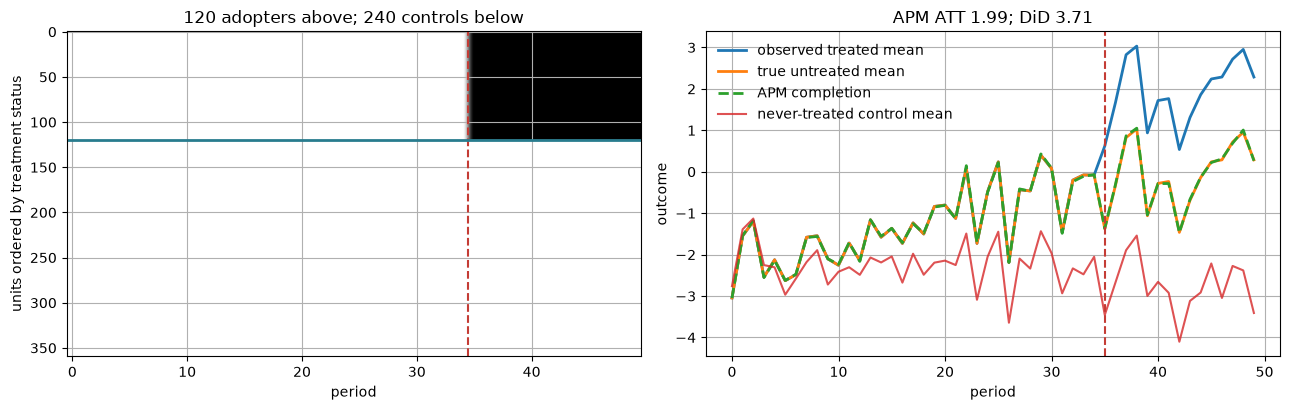

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

rect_unit_order = np.concatenate((treated, controls))
axes[0].imshow(~observed_rect[rect_unit_order], aspect="auto", cmap="Greys")
axes[0].axvline(RECTANGULAR_ADOPTION - 0.5, color="#c43c35", ls="--")
axes[0].axhline(len(treated) - 0.5, color="#287c8e", lw=2)
axes[0].set(
    title="120 adopters above; 240 controls below",
    xlabel="period",
    ylabel="units ordered by treatment status",
)

rect_counterfactual = rect_fit["counterfactual_by_unit"][treated].mean(axis=0)
axes[1].plot(y_rect[treated].mean(axis=0), label="observed treated mean", lw=2)
axes[1].plot(y0[treated].mean(axis=0), label="true untreated mean", lw=2)
axes[1].plot(rect_counterfactual, label="APM completion", lw=2, ls="--")
axes[1].plot(
    y_rect[controls].mean(axis=0),
    label="never-treated control mean",
    lw=1.5,
    alpha=0.8,
)
axes[1].axvline(RECTANGULAR_ADOPTION, color="#c43c35", ls="--")
axes[1].set(
    title=f"APM ATT {rect_metrics['ATT estimate']:.2f}; DiD {rect_did:.2f}",
    xlabel="period",
    ylabel="outcome",
)
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()

## B. Jagged missingness: staggered one-shot adoption and pre-period gaps

The same 120 high-loading units adopt only once, now in four equally sized groups in periods 28, 33, 38, and 43; the 240 control units remain never treated and fully observed. Three adopter cohorts also lose different administrative pre-period observations. The resulting masks overlap enough to identify the factor space, but they are neither a shared prefix nor a common rectangular block.

A regression routine written for section A would require every treated row to expose the same columns. It now fails its design check. One could truncate to the intersection or fit many separate regressions, but both choices discard the shared spectral structure that APM aligns directly.

In [6]:
jagged_adoption = np.full(N_UNITS, N_PERIODS + 1, dtype=np.int64)
pre_period_gaps = [np.array([], dtype=np.int64) for _ in range(N_UNITS)]
adoption_schedule = [28, 33, 38, 43]
gap_schedule = [
    [],
    [6, 12, 18, 24],
    [4, 5, 14, 15, 25, 26],
    list(range(7, 35, 6)),
]

for adoption, gaps, units in zip(
    adoption_schedule, gap_schedule, np.array_split(treated, 4)
):
    jagged_adoption[units] = adoption
    gaps = np.asarray([period for period in gaps if period < adoption], dtype=np.int64)
    for unit in units:
        pre_period_gaps[unit] = gaps

y_jagged, y_jagged_for_factors, observed_jagged, target_jagged = (
    build_treatment_design(y0, treated, jagged_adoption, pre_period_gaps)
)


def require_common_regression_columns(observed_mask, units):
    treated_masks = observed_mask[units]
    if not np.all(treated_masks == treated_masks[0]):
        raise ValueError("treated units do not share one rectangular design matrix")
    return np.flatnonzero(treated_masks[0])


try:
    require_common_regression_columns(observed_jagged, treated)
except ValueError as error:
    print(f"Common-design regression check: {error}")

jagged_fit = fit_apm_completion(y_jagged_for_factors, MODEL_RANK)
jagged_metrics = evaluate_att(y_jagged, y0, target_jagged, jagged_fit)
print()
print_results("Jagged design", jagged_fit, jagged_metrics)

Common-design regression check: treated units do not share one rectangular design matrix

Jagged design
cohort  units  observed periods  first:last
     0     30                28  0:27
     1     30                29  0:32
     2     30                32  0:37
     3     30                38  0:42
     4    240                50  0:49

              ATT estimate:  2.0057
                  true ATT:  2.0000
                 ATT error:  0.0057
  counterfactual-mean RMSE:  0.0399


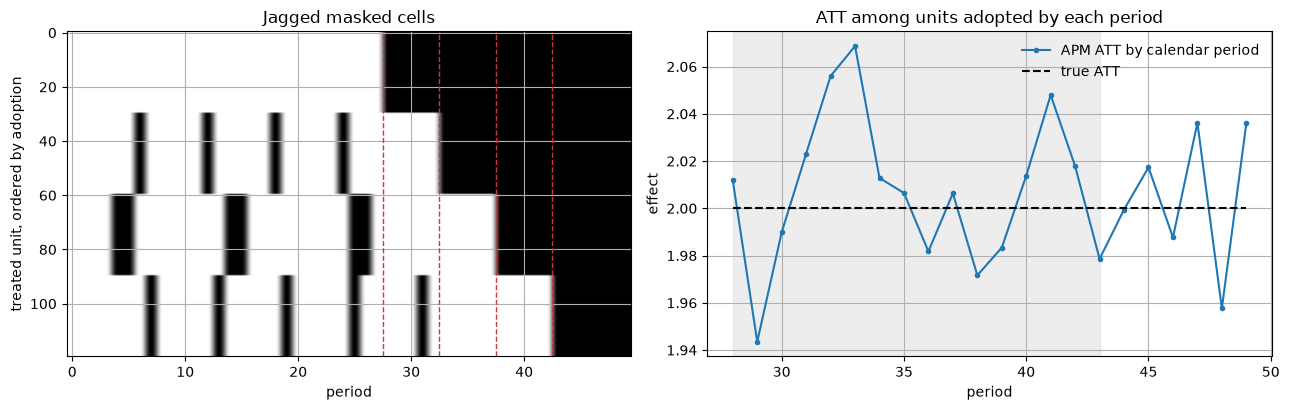

In [7]:
ordered_treated = treated[np.argsort(jagged_adoption[treated], kind="stable")]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].imshow(~observed_jagged[ordered_treated], aspect="auto", cmap="Greys")
for adoption in adoption_schedule:
    axes[0].axvline(adoption - 0.5, color="#c43c35", lw=1, ls="--")
axes[0].set(
    title="Jagged masked cells",
    xlabel="period",
    ylabel="treated unit, ordered by adoption",
)

att_path = np.full(N_PERIODS, np.nan)
true_path = np.full(N_PERIODS, np.nan)
jagged_counterfactual = jagged_fit["counterfactual_by_unit"]
for period in range(N_PERIODS):
    at_risk = np.flatnonzero(target_jagged[:, period])
    if len(at_risk):
        att_path[period] = np.mean(
            y_jagged[at_risk, period] - jagged_counterfactual[at_risk, period]
        )
        true_path[period] = np.mean(
            y_jagged[at_risk, period] - y0[at_risk, period]
        )

axes[1].plot(att_path, marker="o", ms=3, label="APM ATT by calendar period")
axes[1].plot(true_path, color="black", ls="--", label="true ATT")
axes[1].axvspan(
    min(adoption_schedule), max(adoption_schedule), color="#dddddd", alpha=0.5
)
axes[1].set(
    title="ATT among units adopted by each period",
    xlabel="period",
    ylabel="effect",
)
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()

## Comparison

The relevant prediction target is a **cohort counterfactual mean**, not an individual untreated outcome. The RMSE below therefore compares each completed cohort-period mean with its simulated $Y(0)$ mean and weights by the number of treated unit-period cells represented. The rectangular naive DiD is reported separately because its identifying parallel-trends restriction differs from the factor model and there is no analogous common two-by-two contrast for the jagged design.

In [8]:
header = (
    f"{'design':<14} {'ATT estimate':>14} {'true ATT':>10}"
    f" {'ATT error':>11} {'mean RMSE':>12}"
)
print(header)
print("-" * len(header))
for name, metrics in [("rectangular", rect_metrics), ("jagged", jagged_metrics)]:
    print(
        f"{name:<14} "
        f"{metrics['ATT estimate']:>14.4f} "
        f"{metrics['true ATT']:>10.4f} "
        f"{metrics['ATT error']:>11.4f} "
        f"{metrics['counterfactual-mean RMSE']:>12.4f}"
    )

print()
print(f"rectangular naive DiD: {rect_did:.4f}")
print(f"rectangular naive DiD bias: {rect_did - TAU:.4f}")

design           ATT estimate   true ATT   ATT error    mean RMSE
-----------------------------------------------------------------
rectangular            1.9934     2.0000     -0.0066       0.0276
jagged                 2.0057     2.0000      0.0057       0.0399

rectangular naive DiD: 3.7134
rectangular naive DiD bias: 1.7134


## Takeaways

- Rectangular matrix completion is the two-cohort special case: pre-period outcomes for the selected adopter subset plus all-period outcomes for the never-treated controls.
- Selecting adopters for high trend-factor loadings violates parallel trends by construction. The naive DiD includes that untreated trend difference, while APM estimates the latent factor structure.
- Jagged missingness creates several locally estimable factor spaces. APM uses their overlapping observed periods to place them in one global factor space before completion.
- ATT aggregation is unchanged: average observed treated outcomes minus completed untreated cohort means over the post-adoption target cells.
- The factor rank is known in this simulation. In applications it should be selected or subjected to sensitivity analysis, and uncertainty should use the package's weighted bootstrap rather than treating the point estimates above as known.